In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
import seaborn as sns


In [102]:
# chip 3, no bor, no stm programmer
# conn = sqlite3.connect('../../../databases/stm8l_profiling.py_20250920_024157.sqlite')
# chip 3, no bor, no stm programmer
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_133059.sqlite')
# chip 3, no bor, with stm programmer
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_142222.sqlite')
# chip 3, bor, with stm programmer
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_145136.sqlite')

# chip 3, bor, with stm programmer, voltage = 1.23V, length = 24
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_154319.sqlite')
# chip 3, bor, with stm programmer, voltage = 1.19V, length = 24
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_154841.sqlite')

# chip 3, bor, with stm programmer, fixed voltage with double multiplexing
# conn = sqlite3.connect('../../../databases/profiling.py_20250923_100739.sqlite')


# chip 2, bor, clean glitch
conn = sqlite3.connect('../../../databases/profiling.py_20250927_235744.sqlite')

# chip 2, bor, ringing glitch
# conn = sqlite3.connect('../../../databases/profiling.py_20250929_093728.sqlite')

In [103]:
df = pd.read_sql("SELECT * FROM experiments", conn)

df['voltage'] = df['voltage'] / 100
df['response'] = df['response'].astype(str)

df.head()

,id,voltage,delay,length,color,response
0,13500,0.25,1888,108,C,reset
1,13505,0.25,1876,108,C,reset
2,13509,0.25,1888,108,C,reset
3,13515,0.25,1880,108,C,reset
4,13518,0.25,1888,108,C,reset


In [104]:
df[df["response"] == "success"].groupby(["voltage", "length"]).size().sort_values(
    ascending=False
).head(20)

voltage  length
1.21     136       1
1.41     268       1
1.78     344       1
1.71     332       1
1.59     208       1
1.57     320       1
1.56     364       1
1.51     416       1
1.49     268       1
1.46     372       1
1.43     268       1
1.42     416       1
1.41     404       1
         320       1
1.39     352       1
1.22     252       1
1.36     260       1
1.35     420       1
1.34     372       1
1.33     416       1
dtype: int64

In [105]:
# compute overall success rate
df['is_success'] = df['response'] == 'success'
latest_id  = df['id'].max()
success_rate = df['is_success'].sum() / latest_id
print(f"Overall success rate: {success_rate:.2%} ({df['is_success'].sum()} / {latest_id})")

Overall success rate: 0.00% (29 / 6768038)


In [106]:
df[df['response']=='success']['delay'].value_counts()


delay
1888    10
1880     9
1892     4
1884     3
1876     3
Name: count, dtype: int64

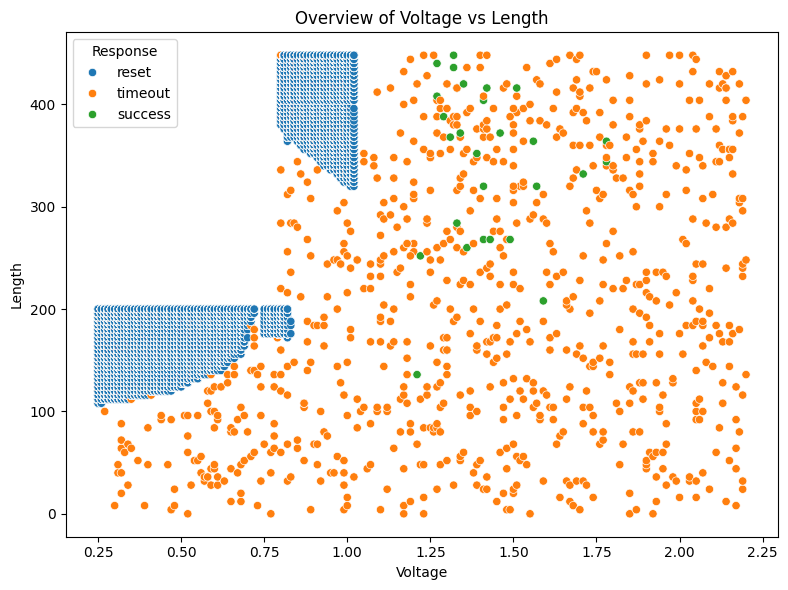

In [107]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="voltage", y="length", hue="response")

plt.title("Overview of Voltage vs Length")
plt.xlabel("Voltage")
plt.ylabel("Length")
plt.legend(title="Response", loc="upper left")
plt.tight_layout()
plt.show()


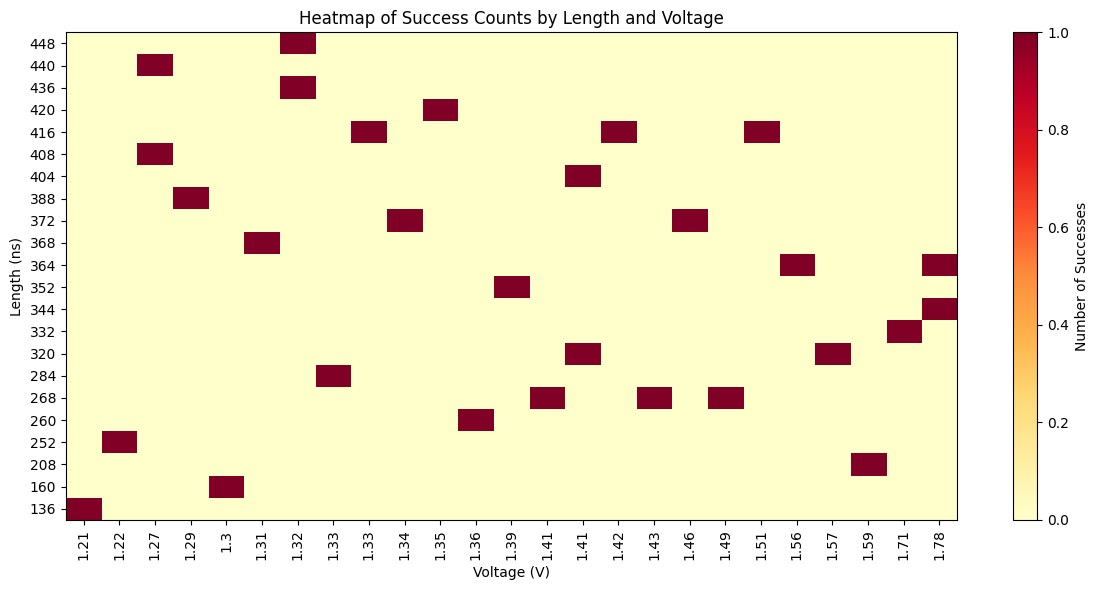

In [108]:
success_counts = df[df['response'] == 'success'].groupby(['length', 'voltage']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
plt.imshow(success_counts, aspect='auto', cmap='YlOrRd', origin='lower')
plt.colorbar(label='Number of Successes')
plt.xticks(ticks=np.arange(len(success_counts.columns)), labels=np.round(success_counts.columns, 2), rotation=90)
plt.yticks(ticks=np.arange(len(success_counts.index)), labels=success_counts.index)
plt.xlabel('Voltage (V)')
plt.ylabel('Length (ns)')
plt.title('Heatmap of Success Counts by Length and Voltage')
plt.tight_layout()
plt.show()


In [109]:
 
df_count = df[df['response'] == 'reset']['voltage'].value_counts()
# plt.bar(df_count.index / 100, df_count.values, width,=0.02, alpha=0.3, label='Reset Count', color='gray', align='center')
df_count

voltage
1.00    14995
0.99    14555
0.98    14232
0.97    13953
0.96    13447
        ...  
0.71     1038
1.02      614
0.75       39
0.72       10
0.83        5
Name: count, Length: 80, dtype: int64

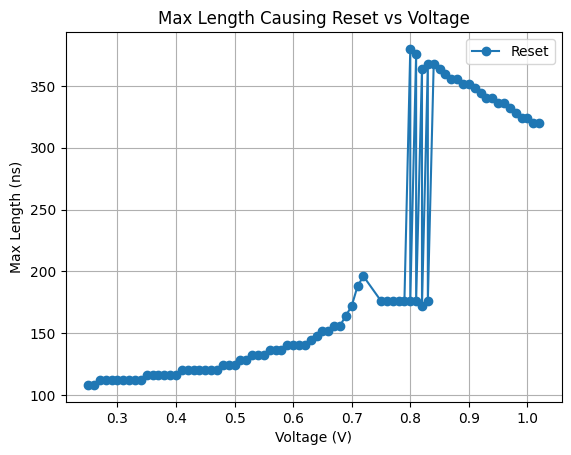

In [110]:
df_reset = pd.read_sql("SELECT voltage, min(length) from experiments where cast(response as text) = 'reset' group by voltage", conn)
plt.plot(df_reset['voltage'] / 100, df_reset['min(length)'], marker='o', label='Reset')
# plot count of resets as bars on the background on second y axis
plt.xlabel('Voltage (V)')
plt.ylabel('Max Length (ns)')
plt.title('Max Length Causing Reset vs Voltage')
plt.grid()
plt.legend()
plt.show()

```sql
SELECT 
    response,
    COUNT(*) AS group_count,
    ROUND( COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2 ) AS percentage
FROM experiments
GROUP BY response;
```